In [1]:
# code taken from prac 9 Bank Deposit Prediction notebook
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName('project').getOrCreate()
df = spark.read.csv('hdfs://namenode/Project/Project/Final_Balanced_Autoimmune_Disorder_Dataset.csv', header = True, inferSchema = True)
df2 = spark.read.csv('hdfs://namenode/Project/Project/Autoimmune_Disorder_10k_with_All_Disorders.csv', header = True, inferSchema = True)
# If does not work
#df = spark.read.csv('hdfs://namenode/Project/Final_Balanced_Autoimmune_Disorder_Dataset.csv', header = True, inferSchema = True)
#df2 = spark.read.csv('hdfs://namenode/Project/Autoimmune_Disorder_10k_with_All_Disorders.csv', header = True, inferSchema = True)
df.printSchema()

root
 |-- Patient_ID: integer (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Diagnosis: string (nullable = true)
 |-- Sickness_Duration_Months: integer (nullable = true)
 |-- RBC_Count: double (nullable = true)
 |-- Hemoglobin: double (nullable = true)
 |-- Hematocrit: double (nullable = true)
 |-- MCV: double (nullable = true)
 |-- MCH: double (nullable = true)
 |-- MCHC: double (nullable = true)
 |-- RDW: double (nullable = true)
 |-- Reticulocyte_Count: double (nullable = true)
 |-- WBC_Count: integer (nullable = true)
 |-- Neutrophils: double (nullable = true)
 |-- Lymphocytes: double (nullable = true)
 |-- Monocytes: double (nullable = true)
 |-- Eosinophils: double (nullable = true)
 |-- Basophils: double (nullable = true)
 |-- PLT_Count: integer (nullable = true)
 |-- MPV: double (nullable = true)
 |-- ANA: integer (nullable = true)
 |-- Esbach: double (nullable = true)
 |-- MBL_Level: double (nullable = true)
 |-- ESR: integer (

In [2]:
# Only keep important columns
df = df.select('Age', 'Gender', 'Diagnosis', 
               'Sickness_Duration_Months', 'RBC_Count', 
               'Low-grade fever', 'Fatigue or chronic tiredness', 
               'Dizziness', 'Weight loss', 'Rashes and skin lesions', 
               'Stiffness in the joints', 'Brittle hair or hair loss', 
                'Dry eyes and/or mouth', "General 'unwell' feeling", 'Joint pain' )
cols = df.columns
df.printSchema()

root
 |-- Age: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Diagnosis: string (nullable = true)
 |-- Sickness_Duration_Months: integer (nullable = true)
 |-- RBC_Count: double (nullable = true)
 |-- Low-grade fever: integer (nullable = true)
 |-- Fatigue or chronic tiredness: integer (nullable = true)
 |-- Dizziness: integer (nullable = true)
 |-- Weight loss: integer (nullable = true)
 |-- Rashes and skin lesions: integer (nullable = true)
 |-- Stiffness in the joints: integer (nullable = true)
 |-- Brittle hair or hair loss: integer (nullable = true)
 |-- Dry eyes and/or mouth: integer (nullable = true)
 |-- General 'unwell' feeling: integer (nullable = true)
 |-- Joint pain: integer (nullable = true)



In [3]:
import pandas as pd
pd.DataFrame(df.take(5), columns=df.columns).transpose()

,0,1,2,3,4
Age,62,54,34,22,20
Gender,Male,Female,Male,Male,Female
Diagnosis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis
Sickness_Duration_Months,41,41,86,43,50
RBC_Count,4.75,4.32,4.42,4.33,3.99
Low-grade fever,0,1,1,0,0
Fatigue or chronic tiredness,1,0,0,1,1
Dizziness,0,1,0,0,1
Weight loss,0,0,1,1,1
Rashes and skin lesions,1,1,1,0,1


In [4]:
num_rows = df.count()
print(f"Number of records: {num_rows}")

Number of records: 11712


### Missing values

In [5]:
df = df.na.drop()

In [6]:
num_rows = df.count()
print(f"Number of records: {num_rows}")

Number of records: 11712


### Visualisation

In [7]:
# Code taken from https://www.geeksforgeeks.org/python/matplotlib-tutorial/

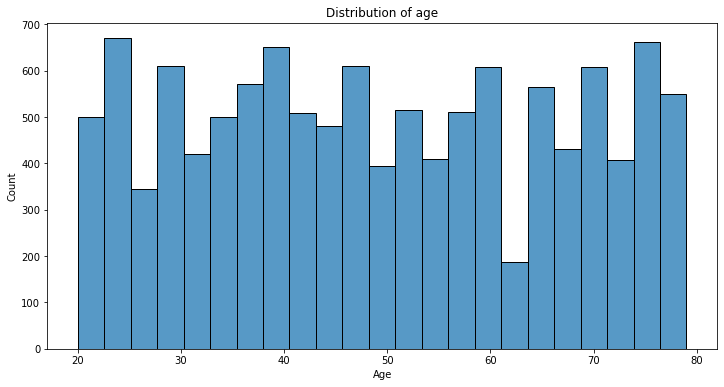

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pandas_df = df.toPandas()

plt.figure(figsize=(12, 6))
sns.histplot(data=pandas_df, x="Age")
plt.title("Distribution of age")
plt.show()

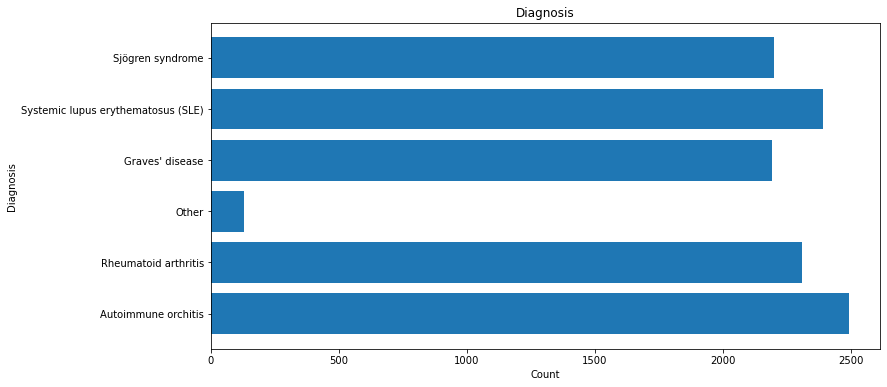

In [9]:
from pyspark.sql.functions import count
counts = df.groupBy("Diagnosis").count()
pandas_df = counts.toPandas()

plt.figure(figsize=(12, 6))
plt.barh(pandas_df["Diagnosis"], pandas_df["count"])
plt.title('Diagnosis')
plt.xlabel('Count')
plt.ylabel('Diagnosis')
plt.show()

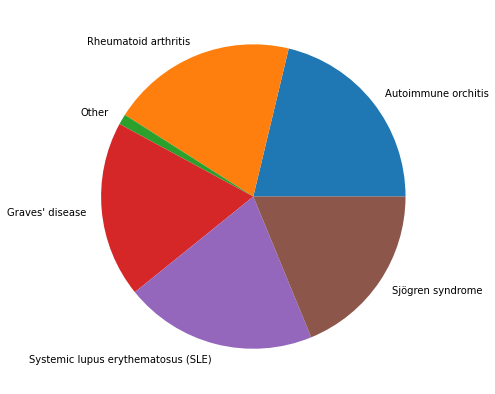

In [10]:
fig = plt.figure(figsize=(10, 7))
plt.pie(pandas_df["count"], labels=pandas_df["Diagnosis"])
plt.show()

In [11]:
from pyspark.sql.functions import countDistinct

# Second dataset has a more detailed number of different disease
df2.select(countDistinct("Diagnosis").alias("distinct disease count")).show()

+----------------------+
|distinct disease count|
+----------------------+
|                   116|
+----------------------+



## Prepare data

In [12]:
from pyspark.ml.feature import OneHotEncoder, StringIndexer, VectorAssembler

# Assigns numeric index to each diagnosis
# Turns indices to one-hot encoded vectors 
categoricalColumns = ['Diagnosis']
stages = []
for categoricalCol in categoricalColumns:
    stringIndexer = StringIndexer(inputCol = categoricalCol, outputCol = categoricalCol + 'Index')
    encoder = OneHotEncoder(inputCols=[stringIndexer.getOutputCol()], outputCols=[categoricalCol + "classVec"])
    stages += [stringIndexer, encoder]

# Converts the target gender column into a numeric column
label_stringIdx = StringIndexer(inputCol = 'Gender', outputCol = 'label')
stages += [label_stringIdx]

# Combine all features into a single feature vector column
numericCols = ['Age', 'Sickness_Duration_Months', 'RBC_Count', 
               'Low-grade fever', 'Fatigue or chronic tiredness', 
               'Dizziness', 'Weight loss', 'Rashes and skin lesions', 
               'Stiffness in the joints', 'Brittle hair or hair loss', 
                'Dry eyes and/or mouth', "General 'unwell' feeling", 'Joint pain']
assemblerInputs = [c + "classVec" for c in categoricalColumns] + numericCols
assembler = VectorAssembler(inputCols=assemblerInputs, outputCol="features")
stages += [assembler]

In [13]:
from pyspark.ml import Pipeline

# Create and fit pipeline on the dataframe
pipeline = Pipeline(stages = stages)
pipelineModel = pipeline.fit(df)

# Transform dataframe and select final columns for modelling
df = pipelineModel.transform(df)
selectedCols = ['label', 'features'] + cols
df = df.select(selectedCols)

In [14]:
pd.DataFrame(df.take(5), columns=df.columns).transpose()

,0,1,2,3,4
label,0,1,0,0,1
features,"(1.0, 0.0, 0.0, 0.0, 0.0, 62.0, 41.0, 4.75, 0....","[1.0, 0.0, 0.0, 0.0, 0.0, 54.0, 41.0, 4.32, 1....","(1.0, 0.0, 0.0, 0.0, 0.0, 34.0, 86.0, 4.42, 1....","(1.0, 0.0, 0.0, 0.0, 0.0, 22.0, 43.0, 4.33, 0....","[1.0, 0.0, 0.0, 0.0, 0.0, 20.0, 50.0, 3.99, 0...."
Age,62,54,34,22,20
Gender,Male,Female,Male,Male,Female
Diagnosis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis
Sickness_Duration_Months,41,41,86,43,50
RBC_Count,4.75,4.32,4.42,4.33,3.99
Low-grade fever,0,1,1,0,0
Fatigue or chronic tiredness,1,0,0,1,1
Dizziness,0,1,0,0,1


In [15]:
# Split into train and test for machine learning tasks
train, test = df.randomSplit([0.7, 0.3], seed = 2018)
print("Training Dataset Count: " + str(train.count()))
print("Test Dataset Count: " + str(test.count()))

Training Dataset Count: 8240
Test Dataset Count: 3472


## Logistic Regression

In [16]:
from pyspark.ml.classification import LogisticRegression

# Logistic regression model using the target Gender column and
# all other features 
lr = LogisticRegression(featuresCol = 'features', labelCol = 'label', maxIter=10)
lrModel = lr.fit(train)

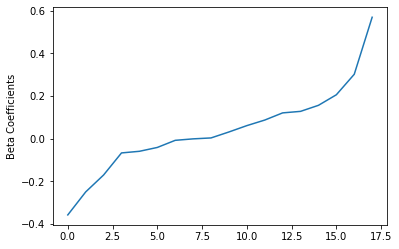

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Vector of all learned coefficients (how strongly each feature
# contributes to predicting the gender)
beta = np.sort(lrModel.coefficients)
plt.plot(beta)
plt.ylabel('Beta Coefficients')
plt.show()

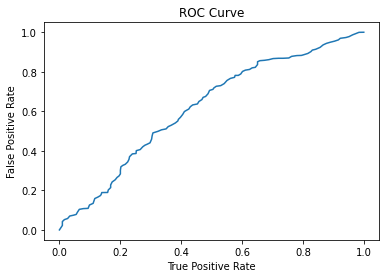

Training set areaUnderROC: 0.6184884911633255


In [18]:
# Summary of evaluation metrics 
trainingSummary = lrModel.summary

# ROC: trade-off between correctly identifying positives 
# and incorrectly labeling negatives as positive
# A good model has a ROC curve closer to the top-left corner
roc = trainingSummary.roc.toPandas()

plt.plot(roc['FPR'],roc['TPR'])
plt.ylabel('False Positive Rate')
plt.xlabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

print('Training set areaUnderROC: ' + str(trainingSummary.areaUnderROC))

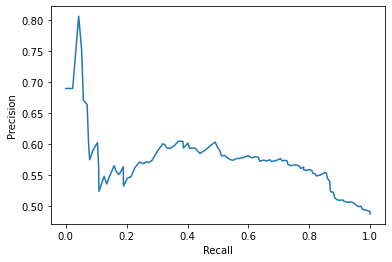

In [19]:
# Recall: how many actual positives were correctly identified
# Precision: How many positive instances were actually positive
pr = trainingSummary.pr.toPandas()
plt.plot(pr['recall'],pr['precision'])
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.show()

In [20]:
predictions = lrModel.transform(test)
logistics = predictions.select('Gender', 'Diagnosis', 'label', 'rawPrediction', 'prediction', 'probability' )
pd.DataFrame(logistics.take(5), columns=logistics.columns).transpose()

,0,1,2,3,4
Gender,Male,Male,Male,Male,Male
Diagnosis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis
label,0,0,0,0,0
rawPrediction,"[0.15659739242716023, -0.15659739242716023]","[0.15659739242716023, -0.15659739242716023]","[0.15659739242716023, -0.15659739242716023]","[0.15659739242716023, -0.15659739242716023]","[-0.22036532802602818, 0.22036532802602818]"
prediction,0,0,0,0,1
probability,"[0.5390695396953159, 0.46093046030468404]","[0.5390695396953159, 0.46093046030468404]","[0.5390695396953159, 0.46093046030468404]","[0.5390695396953159, 0.46093046030468404]","[0.445130530956486, 0.5548694690435141]"


## Random Forest Classifier

In [21]:
from pyspark.ml.classification import RandomForestClassifier

# Ensemble of decision trees
# Each tree votes on classification and majority vote is taken
rf = RandomForestClassifier(featuresCol = 'features', labelCol = 'label')
rfModel = rf.fit(train)
predictions = rfModel.transform(test)
classifier = predictions.select('Gender', 'Diagnosis', 'label', 'rawPrediction', 'prediction', 'probability' )
pd.DataFrame(classifier.take(5), columns=classifier.columns).transpose()

,0,1,2,3,4
Gender,Male,Male,Male,Male,Male
Diagnosis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis
label,0,0,0,0,0
rawPrediction,"[11.065395461095106, 8.934604538904896]","[11.065395461095106, 8.934604538904896]","[11.065395461095106, 8.934604538904896]","[11.065395461095106, 8.934604538904896]","[9.576067096899896, 10.423932903100104]"
prediction,0,0,0,0,1
probability,"[0.5532697730547553, 0.4467302269452448]","[0.5532697730547553, 0.4467302269452448]","[0.5532697730547553, 0.4467302269452448]","[0.5532697730547553, 0.4467302269452448]","[0.4788033548449948, 0.5211966451550052]"


In [22]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
evaluator = BinaryClassificationEvaluator()
print("Test Area Under ROC: " + str(evaluator.evaluate(predictions, {evaluator.metricName: "areaUnderROC"})))

Test Area Under ROC: 0.8696179790493083


## K-Means Clustering

In [23]:
# code taken from SparkMLlib
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# Iteratively assings each point to the nearest cluster center 
# and updates cluster centers based on assigned points
kmeans = KMeans().setK(2).setSeed(1)
model = kmeans.fit(train)

# Make predictions
predictions = model.transform(test)

# Evaluate clustering by computing Silhouette score
# Closer to 1: points are well-clustered
evaluator = ClusteringEvaluator()
silhouette = evaluator.evaluate(predictions)
print("Silhouette with squared euclidean distance = " + str(silhouette))

Silhouette with squared euclidean distance = 0.6845639790334969


In [24]:
classifier = predictions.select('Gender', 'Diagnosis', 'label', 'prediction')
pd.DataFrame(classifier.take(5), columns=classifier.columns).transpose()

,0,1,2,3,4
Gender,Male,Male,Male,Male,Male
Diagnosis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis,Autoimmune orchitis
label,0,0,0,0,0
prediction,0,0,0,0,1


## Frequent Pattern Mining

In [25]:
from pyspark.sql.functions import array, col

# Combine columns into a single array
df_items = df.select(array("Gender", "Diagnosis").alias("Items"))

In [26]:
from pyspark.ml.fpm import FPGrowth

fpGrowth = FPGrowth(itemsCol="Items", minSupport=0.001, minConfidence=0.0)
model = fpGrowth.fit(df_items)

# Display frequent itemsets.
model.freqItemsets.show()

# Display generated association rules.
# antecedent: if these items appear
# consequent: then these items appear
# confidence: probability
# lift: how much larger than random
model.associationRules.sort("antecedent", "consequent").show(5)

# transform examines the input items against all the association rules and summarize the
# consequents as prediction
model.transform(df_items).show()

+--------------------+----+
|               items|freq|
+--------------------+----+
|[Autoimmune orchi...|2490|
|[Autoimmune orchi...|1179|
|[Autoimmune orchi...|1311|
|  [Sjögren syndrome]|2200|
|[Sjögren syndrome...|1242|
|[Sjögren syndrome...| 958|
|[Rheumatoid arthr...|2310|
|[Rheumatoid arthr...| 962|
|[Rheumatoid arthr...|1348|
|             [Other]| 130|
|     [Other, Female]|  56|
|       [Other, Male]|  74|
|            [Female]|5765|
|[Systemic lupus e...|2390|
|[Systemic lupus e...|1211|
|[Systemic lupus e...|1179|
|   [Graves' disease]|2192|
|[Graves' disease,...|1115|
|[Graves' disease,...|1077|
|              [Male]|5947|
+--------------------+----+

+--------------------+--------------------+-------------------+------------------+
|          antecedent|          consequent|         confidence|              lift|
+--------------------+--------------------+-------------------+------------------+
|[Autoimmune orchi...|            [Female]| 0.4734939759036145|0.9619360703873

### Compare with another dataset

In [27]:
df2_items = df2.select(array("Gender", "Diagnosis").alias("Items"))

fpGrowth = FPGrowth(itemsCol="Items", minSupport=0.001, minConfidence=0.0)
model = fpGrowth.fit(df2_items)

model.freqItemsets.show()

model.associationRules.sort("antecedent", "consequent").show(5)

model.transform(df2_items).show()

+--------------------+----+
|               items|freq|
+--------------------+----+
|[Lambert–Eaton my...|  78|
|[Lambert–Eaton my...|  37|
|[Lambert–Eaton my...|  41|
|[Autoimmune pancr...|  76|
|[Autoimmune pancr...|  37|
|[Autoimmune pancr...|  39|
|    [Optic neuritis]|  79|
|[Optic neuritis, ...|  29|
|[Optic neuritis, ...|  50|
|[Hashimoto's thyr...|  72|
|[Hashimoto's thyr...|  39|
|[Hashimoto's thyr...|  33|
|   [Lupus nephritis]|  75|
|[Lupus nephritis,...|  33|
|[Lupus nephritis,...|  42|
|[Undifferentiated...|  77|
|[Undifferentiated...|  35|
|[Undifferentiated...|  42|
|[Neuromyelitis op...|  92|
|[Neuromyelitis op...|  40|
+--------------------+----+
only showing top 20 rows

+--------------------+----------+-------------------+------------------+
|          antecedent|consequent|         confidence|              lift|
+--------------------+----------+-------------------+------------------+
|[Acute disseminat...|  [Female]|0.43529411764705883|0.8798797656190549|
|[Acute di